### Применение условных вероятностей в анализе данных

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('F1DriversDataset.csv')
print('Размер данных:', df.shape)

Размер данных: (868, 22)


In [11]:
df.head()

,Driver,Nationality,Seasons,Championships,Race_Entries,Race_Starts,Pole_Positions,Race_Wins,Podiums,Fastest_Laps,...,Championship Years,Decade,Pole_Rate,Start_Rate,Win_Rate,Podium_Rate,FastLap_Rate,Points_Per_Entry,Years_Active,Champion
0,Carlo Abate,Italy,"[1962, 1963]",0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,NaN,1960,0.0,0.000000,0.0,0.0,0.0,0.000000,2,False
1,George Abecassis,United Kingdom,"[1951, 1952]",0.0,2.0,2.0,0.0,0.0,0.0,0.0,...,NaN,1950,0.0,1.000000,0.0,0.0,0.0,0.000000,2,False
2,Kenny Acheson,United Kingdom,"[1983, 1985]",0.0,10.0,3.0,0.0,0.0,0.0,0.0,...,NaN,1980,0.0,0.300000,0.0,0.0,0.0,0.000000,2,False
3,Andrea de Adamich,Italy,"[1968, 1970, 1971, 1972, 1973]",0.0,36.0,30.0,0.0,0.0,0.0,0.0,...,NaN,1970,0.0,0.833333,0.0,0.0,0.0,0.166667,5,False
4,Philippe Adams,Belgium,[1994],0.0,2.0,2.0,0.0,0.0,0.0,0.0,...,NaN,1990,0.0,1.000000,0.0,0.0,0.0,0.000000,1,False


In [12]:
print('\nСтолбцы:', df.columns.tolist())


Столбцы: ['Driver', 'Nationality', 'Seasons', 'Championships', 'Race_Entries', 'Race_Starts', 'Pole_Positions', 'Race_Wins', 'Podiums', 'Fastest_Laps', 'Points', 'Active', 'Championship Years', 'Decade', 'Pole_Rate', 'Start_Rate', 'Win_Rate', 'Podium_Rate', 'FastLap_Rate', 'Points_Per_Entry', 'Years_Active', 'Champion']


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 868 entries, 0 to 867
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Driver              868 non-null    object 
 1   Nationality         868 non-null    object 
 2   Seasons             868 non-null    object 
 3   Championships       868 non-null    float64
 4   Race_Entries        868 non-null    float64
 5   Race_Starts         868 non-null    float64
 6   Pole_Positions      868 non-null    float64
 7   Race_Wins           868 non-null    float64
 8   Podiums             868 non-null    float64
 9   Fastest_Laps        868 non-null    float64
 10  Points              868 non-null    float64
 11  Active              868 non-null    bool   
 12  Championship Years  34 non-null     object 
 13  Decade              868 non-null    int64  
 14  Pole_Rate           868 non-null    float64
 15  Start_Rate          868 non-null    float64
 16  Win_Rate

In [14]:
print('Пропущенные значения')
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
pd.DataFrame({'Количество пропусков:' : missing_data,
              'Процент пропусков:' : missing_percent.round(2)})

Пропущенные значения


,Количество пропусков:,Процент пропусков:
Driver,0,0.00
Nationality,0,0.00
Seasons,0,0.00
Championships,0,0.00
Race_Entries,0,0.00
Race_Starts,0,0.00
Pole_Positions,0,0.00
Race_Wins,0,0.00
Podiums,0,0.00
Fastest_Laps,0,0.00


In [28]:
print('Доля чемпионов по национальности и наличию побед')
df['Is_Champion'] = (df['Championships'] > 0).astype(int)
df['Has_Wins'] = (df['Race_Wins'] > 0).astype(int)

pivot = pd.pivot_table(
    df,
    values='Is_Champion',
    index='Nationality',
    columns='Has_Wins',
    aggfunc='mean',
    fill_value=0
)

pivot.round(4)

Доля чемпионов по национальности и наличию побед


Has_Wins,0,1
Nationality,,
Argentina,0.0,0.3333
Australia,0.0,0.5000
Austria,0.0,0.6667
Belgium,0.0,0.0000
Belgium France,0.0,0.0000
Brazil,0.0,0.5000
Canada,0.0,0.5000
Chile,0.0,0.0000
China,0.0,0.0000


### Простые вероятности

In [ ]:
# Общая вероятность быть чемпионом
P_Champ = df['Championships'].mean()
print(f'\nP(Championships) = {P_Champ:.4f}')


P(Championships) = 0.0841


In [20]:
# вероятность быть гонщиком каждой национальности
for pole in sorted(df['Nationality'].unique()):
    P_Pole = (df['Nationality'] == pole).mean()
    print(f'P(Nationality={pole}) = {P_Pole:.4f}')

P(Nationality=Argentina) = 0.0288
P(Nationality=Australia) = 0.0207
P(Nationality=Austria) = 0.0184
P(Nationality=Belgium) = 0.0265
P(Nationality=Belgium France) = 0.0012
P(Nationality=Brazil) = 0.0369
P(Nationality=Canada) = 0.0173
P(Nationality=Chile) = 0.0012
P(Nationality=China) = 0.0012
P(Nationality=Colombia) = 0.0035
P(Nationality=Czech Republic) = 0.0012
P(Nationality=Denmark) = 0.0058
P(Nationality=East Germany) = 0.0035
P(Nationality=East Germany, West Germany) = 0.0012
P(Nationality=Finland) = 0.0104
P(Nationality=France) = 0.0829
P(Nationality=Germany) = 0.0161
P(Nationality=Hungary) = 0.0012
P(Nationality=India) = 0.0023
P(Nationality=Indonesia) = 0.0012
P(Nationality=Ireland) = 0.0058
P(Nationality=Italy) = 0.1141
P(Nationality=Japan) = 0.0242
P(Nationality=Liechtenstein) = 0.0012
P(Nationality=Malaysia) = 0.0012
P(Nationality=Mexico) = 0.0069
P(Nationality=Monaco) = 0.0046
P(Nationality=Monaco Netherlands) = 0.0012
P(Nationality=Morocco) = 0.0012
P(Nationality=Netherland

In [25]:
# вероятность быть победить в гонке хоть раз или не победить
df['Has_Wins'] = df['Race_Wins'] > 0

for val in df['Has_Wins'].unique():
    P = (df['Has_Wins'] == val).mean()
    print(f'P(Has_Wins = {val}) = {P:.3f}')


P(Has_Wins = False) = 0.870
P(Has_Wins = True) = 0.130


### Условная вероятность

Найти вероятность выигать чемпионат, если гонщик был на подиуме 
$$P_{OnPodium}(Champion)=\frac{P(Champion\cdot OnPodium)}{OnPodium}$$

In [29]:
podium = df[df['Podiums'] > 0]
P_Podium = (df['Podiums'] > 0).mean()
P_Champ_and_Podium = ((df['Championships'] > 0) & (df['Podiums'] > 0)).mean()

P_Champ_if_Podium = P_Champ_and_Podium / P_Podium
print(f'\nP(Championships | Podiums) = {P_Champ_if_Podium:.4f}')


P(Championships | Podiums) = 0.1581


In [31]:
podium = df[df['Podiums'] > 0]
P_P_Champ_if_Podium = (podium['Championships'] > 0).mean()
print(f'P(Championships | Podiums), рассчитанная через фильтр: {P_P_Champ_if_Podium:.4f}')

P(Championships | Podiums), рассчитанная через фильтр: 0.1581


Найти вероятность выиграть чемпионат, если у него больше 10 побед
$$P_{Wins}(Champion)=\frac{P(Champion\cdot Wins)}{Wins}$$

In [41]:
wins = df[df['Race_Wins'] > 10]
P_Wins = (df['Race_Wins'] > 10).mean()
P_Champ_and_wins = ((df['Championships'] > 0) & (df['Race_Wins'] > 10)).mean()

P_Champ_if_wins = P_Champ_and_wins / P_Wins
print(f'\nP(Championships | Wins) = {P_Champ_if_wins:.4f}')



P(Championships | Wins) = 0.8333


In [44]:
wins = df[df['Race_Wins'] > 10]
P_P_Champ_if_Wins = (wins['Championships'] > 0).mean()
print(f'P(Championships | Wins), рассчитанная через фильтр: {P_P_Champ_if_Wins:.4f}')

P(Championships | Wins), рассчитанная через фильтр: 0.8333


Найти вероятность выигать чемпионат, если у гонщика есть самый бытрый круг в гонке
$$P_{FastLap}(Champion)=\frac{P(Champion\cdot FastLap)}{FastLap}$$

In [33]:
Fastest_Lap = df[df['Fastest_Laps'] > 0]
P_Fastest_Lap = (df['Fastest_Laps'] > 0).mean()
P_Champ_and_Fastest_Lap = ((df['Championships'] > 0) & (df['Fastest_Laps'] > 0)).mean()

P_Champ_if_Fastest_Lap = P_Champ_and_Fastest_Lap / P_Fastest_Lap
print(f'\nP(Championships | Fastest_Laps) = {P_Champ_if_Fastest_Lap:.4f}')


P(Championships | Fastest_Laps) = 0.2500


In [43]:
fastest_Laps = df[df['Fastest_Laps'] > 0]
P_P_Champ_if_Fastest_Laps = (fastest_Laps['Championships'] > 0).mean()
print(f'P(Championships | Fastest_Laps), рассчитанная через фильтр: {P_P_Champ_if_Fastest_Laps:.4f}')

P(Championships | Fastest_Laps), рассчитанная через фильтр: 0.2500


### Обощение вычисления условных вероятностей

In [45]:
def conditional_probability(df, condition_col, condition_val, target_col, target_val=1):
    subset = df[df[condition_col]==condition_val]
    if len(subset)==0:
        return 0
    return (subset[target_col]==target_val).mean()

In [62]:
print("Условные вероятности чемпионства:")
print('=' * 50)

# Гонщик был на подиуме больше 10 раз
print('По подиумам')
for podium in sorted(df.loc[df['Podiums'] > 10, 'Podiums'].unique()):
    P = conditional_probability(df, 'Podiums', podium, 'Championships')
    print(f'    Podiums = {podium}: P(Championships | Podiums) = {P:.4f}')

# Гонщик имеет больше 10 побед
print('По победам')
for wins in sorted(df.loc[df['Race_Wins'] > 10, 'Race_Wins'].unique()):
    P = conditional_probability(df, 'Race_Wins', wins, 'Championships')
    print(f'    Race_Wins = {wins}: P(Championships | Race_Wins) = {P:.4f}')

# Гонщик имеет самый быстрый круг в гонке
print('По самым быстрым кругам')
for fastest_laps in sorted(df.loc[df['Fastest_Laps'] > 5, 'Fastest_Laps'].unique()):
    P = conditional_probability(df, 'Fastest_Laps', fastest_laps, 'Championships')
    print(f'    Fastest_Laps = {fastest_laps}: P(Championships | Fastest_Laps) = {P:.4f}')

Условные вероятности чемпионства:
По подиумам
    Podiums = 11.0: P(Championships | Podiums) = 0.0000
    Podiums = 12.0: P(Championships | Podiums) = 0.0000
    Podiums = 13.0: P(Championships | Podiums) = 0.2000
    Podiums = 14.0: P(Championships | Podiums) = 0.0000
    Podiums = 15.0: P(Championships | Podiums) = 0.0000
    Podiums = 16.0: P(Championships | Podiums) = 1.0000
    Podiums = 17.0: P(Championships | Podiums) = 0.5000
    Podiums = 18.0: P(Championships | Podiums) = 0.5000
    Podiums = 19.0: P(Championships | Podiums) = 0.2500
    Podiums = 20.0: P(Championships | Podiums) = 0.5000
    Podiums = 22.0: P(Championships | Podiums) = 0.0000
    Podiums = 23.0: P(Championships | Podiums) = 0.6667
    Podiums = 24.0: P(Championships | Podiums) = 0.5000
    Podiums = 25.0: P(Championships | Podiums) = 0.0000
    Podiums = 26.0: P(Championships | Podiums) = 0.0000
    Podiums = 27.0: P(Championships | Podiums) = 0.0000
    Podiums = 28.0: P(Championships | Podiums) = 0.0000
  

### Формула полной вероятности

Mы знаем вероятной чемпионства для различного количества побед. Теперь найдем общую вероятность чемпионства.

In [ ]:
print('Формула полной вероятности')
print('P(Champion) = Σ P(Champion | Race_Wins = i) * P(Race_Wins = i)')
print('=' * 60)

total_prob = 0
prob_details = []

for win in sorted(df['Race_Wins'].unique()):
    mask = df['Race_Wins'] == win
    P_Wins = mask.mean()

    if P_Wins == 0:
        continue

    P_Champ_if_Wins = (df.loc[mask, 'Championships'] > 0).mean()

    contribution = P_Champ_if_Wins * P_Wins
    total_prob += contribution

    prob_details.append({
        'Race_Wins': win,
        'P(Race_Wins)': P_Wins,
        'P(Champion | Race_Wins)': P_Champ_if_Wins,
        'Вклад': contribution
    })

prob_df = pd.DataFrame(prob_details)
print(prob_df.round(4))

print(f'\nИтог по формуле полной вероятности: {total_prob:.4f}')
print(f"Прямая вероятность из данных: {(df['Championships'] > 0).mean():.4f}")


Формула полной вероятности
P(Champion) = Σ P(Champion | Race_Wins = i) * P(Race_Wins = i)
    Race_Wins  P(Race_Wins)  P(Champion | Race_Wins)   Вклад
0         0.0        0.8698                   0.0000  0.0000
1         1.0        0.0415                   0.0000  0.0000
2         2.0        0.0127                   0.0000  0.0000
3         3.0        0.0092                   0.2500  0.0023
4         4.0        0.0046                   0.0000  0.0000
5         5.0        0.0069                   0.3333  0.0023
6         6.0        0.0081                   0.2857  0.0023
7         7.0        0.0023                   0.0000  0.0000
8         8.0        0.0035                   0.3333  0.0012
9         9.0        0.0012                   0.0000  0.0000
10       10.0        0.0058                   0.4000  0.0023
11       11.0        0.0035                   0.3333  0.0012
12       12.0        0.0035                   0.6667  0.0023
13       13.0        0.0023                   0.5000  0.

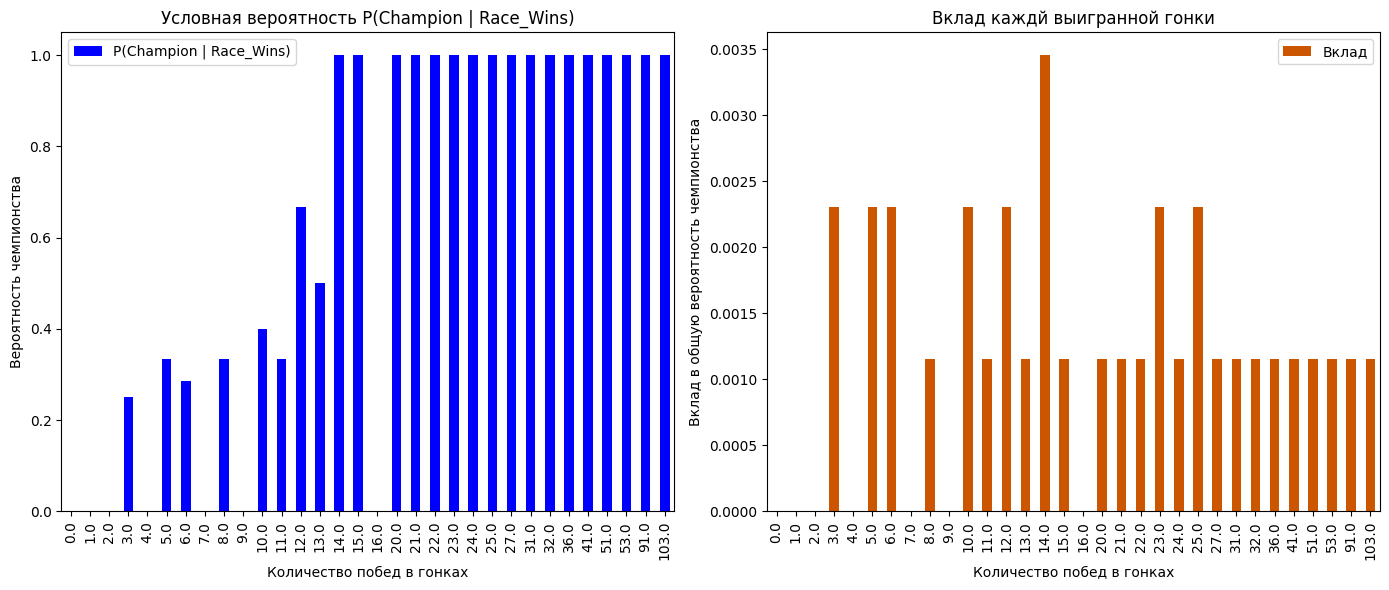

In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

prob_df.plot(x='Race_Wins', y='P(Champion | Race_Wins)', kind='bar', 
             ax=ax1, color='blue')
ax1.set_title('Условная вероятность P(Champion | Race_Wins)')
ax1.set_ylabel('Вероятность чемпионства')
ax1.set_xlabel('Количество побед в гонках')

prob_df.plot(x='Race_Wins', y='Вклад', kind='bar', 
             ax=ax2, color='#cc5500')
ax2.set_title('Вклад каждй выигранной гонки')
ax2.set_ylabel('Вклад в общую вероятность чемпионства')
ax2.set_xlabel('Количество побед в гонках')

plt.tight_layout()
plt.show()


### Теорема Байеса

Мы видим гонщика, о котором известно, что он является чемпионом мира. Информации о его спортивных достижениях (например, подиумах) у нас нет, но мы хотим понять, насколько вероятно, что у него было больше 20 подиумов.\
А: Гонщик имеет n подиумов\
В: Гонщик является чемпионом\
Тогда, по теореме Байеса:
$$P_{Champ}(Podiums>20)=\frac{P(Podiums>n)\cdot P_{Podiums>n}(Champion)}{P(Champion)}$$

In [75]:
print("ТЕОРЕМА БАЙЕСА:")
print("P(Podiums > k | Champion) = P(Champion | Podiums > k) × P(Podiums > k) / P(Champion)")
print("=" * 80)
P_B = (df['Championships'] > 0).mean()

thresholds = [10, 20, 30]
bayes_results = []

for t in thresholds:
    P_A = (df['Podiums'] > t).mean()
    P_B_given_A = (df.loc[df['Podiums'] > t, 'Championships'] > 0).mean()
    P_A_given_B = (P_B_given_A * P_A) / P_B

    bayes_results.append({
        'Событие A': f'Podiums > {t}',
        'P(A)': P_A,
        'P(B | A)': P_B_given_A,
        'P(A | B)': P_A_given_B
    })

bayes_df = pd.DataFrame(bayes_results)

print("Результаты применения теоремы Байеса:")
print(bayes_df.round(4))


ТЕОРЕМА БАЙЕСА:
P(Podiums > k | Champion) = P(Champion | Podiums > k) × P(Podiums > k) / P(Champion)
Результаты применения теоремы Байеса:
      Событие A    P(A)  P(B | A)  P(A | B)
0  Podiums > 10  0.0864    0.4533    1.0000
1  Podiums > 20  0.0576    0.5400    0.7941
2  Podiums > 30  0.0392    0.6765    0.6765


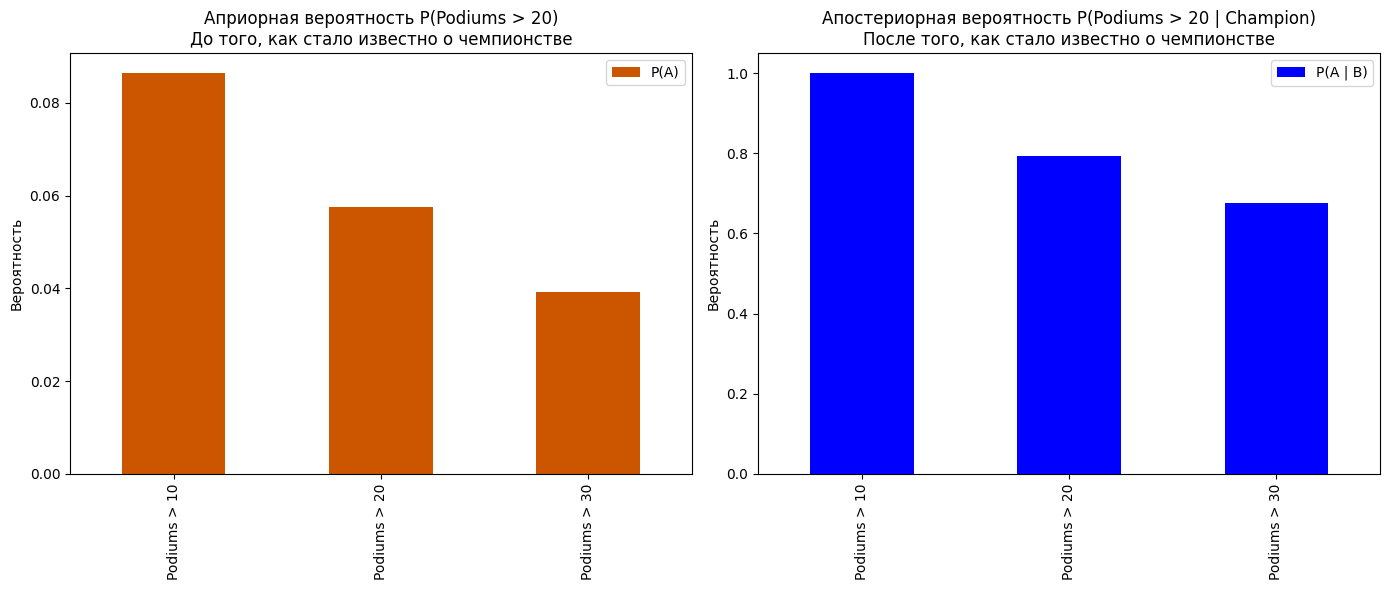

In [76]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Априорная вероятность
bayes_df.plot(
    x='Событие A', y='P(A)', kind='bar',
    ax=ax1,color='#cc5500')
ax1.set_title('Априорная вероятность P(Podiums > 20)\nДо того, как стало известно о чемпионстве')
ax1.set_ylabel('Вероятность')
ax1.set_xlabel('')

# Апостериорная вероятность
bayes_df.plot(x='Событие A', y='P(A | B)', kind='bar',
    ax=ax2, color='blue')
ax2.set_title('Апостериорная вероятность P(Podiums > 20 | Champion)\nПосле того, как стало известно о чемпионстве')
ax2.set_ylabel('Вероятность')
ax2.set_xlabel('')

plt.tight_layout()
plt.show()
